In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)




# Loading Data

In [53]:
# Load dataset
df = pd.read_csv(r'C:\Users\veges\Downloads\archive (4)\diabetes.csv')
df_cleaned = df.copy()

print(f'  Shape    : {df.shape}  ({df.shape[0]} patients, {df.shape[1]} columns)')
print(f'  Outcome  : {df["Outcome"].value_counts().to_dict()}')



  Shape    : (768, 9)  (768 patients, 9 columns)
  Outcome  : {0: 500, 1: 268}


In [54]:

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
print('Missing values after replacing zeros:')
print(df.isnull().sum())
#  Fill with CLASS-WISE MEDIAN 
for col in zero_cols:
    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )
df = df.drop_duplicates().reset_index(drop=True)
print(f'\n Cleaned dataset: {df.shape} | Nulls remaining: {df.isnull().sum().sum()}')

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

 Cleaned dataset: (768, 9) | Nulls remaining: 0


In [55]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [56]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [57]:
 #── Medically meaningful interaction features ─────────────
df['BMI_Age']         = df['BMI'] * df['Age']            # Obesity risk increases with age
df['Glucose_BMI']     = df['Glucose'] * df['BMI']        # Combined metabolic risk
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin']    # Insulin resistance signal
df['BP_Age']          = df['BloodPressure'] * df['Age']  # Hypertension-age interaction
df['Glucose_squared'] = df['Glucose'] ** 2               # Non-linear glucose effect

print(' Feature Engineering Complete!')
print(f'   Dataset shape: {df.shape}')
print(f'   New features : BMI_Age | Glucose_BMI | Glucose_Insulin | BP_Age | Glucose_squared')

 Feature Engineering Complete!
   Dataset shape: (768, 14)
   New features : BMI_Age | Glucose_BMI | Glucose_Insulin | BP_Age | Glucose_squared


# Checking Imbalance Check 

Class Distribution of ORIGINAL dataset (768 real patients):
  No Diabetes (0): 500  (65.1%)
  Diabetes    (1): 268  (34.9%)
  Imbalance Ratio : 1.87:1  — SIGNIFICANT
  Total rows      : 768 (all REAL patient records)

 CORRECT approach:
   Step 1 → Split original 768 rows into train/test (REAL data only in test)
   Step 2 → Oversample ONLY the training set
   Step 3 → Test set stays 100% real — gives honest real-world performance


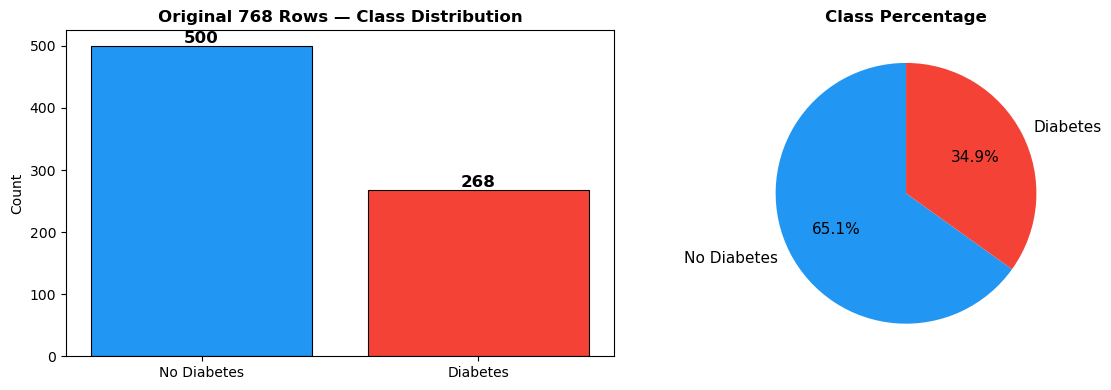

In [58]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

counts = y.value_counts()
print('Class Distribution of ORIGINAL dataset (768 real patients):')
print(f'  No Diabetes (0): {counts[0]}  ({counts[0]/len(y)*100:.1f}%)')
print(f'  Diabetes    (1): {counts[1]}  ({counts[1]/len(y)*100:.1f}%)')
print(f'  Imbalance Ratio : {counts[0]/counts[1]:.2f}:1  — SIGNIFICANT')
print(f'  Total rows      : {len(y)} (all REAL patient records)')
print()
print(' CORRECT approach:')
print('   Step 1 → Split original 768 rows into train/test (REAL data only in test)')
print('   Step 2 → Oversample ONLY the training set')
print('   Step 3 → Test set stays 100% real — gives honest real-world performance')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Diabetes', 'Diabetes'], counts.values, color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Original 768 Rows — Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Percentage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



In [59]:

#  STEP 1: Split ORIGINAL real data into train/test FIRST
#  Test set = 100% real patients. Never touched by oversampling.

feature_names = list(X.columns)

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print('SPLIT RESULT (using original 768 real patients):')
print(f'  Training set (raw) : {len(X_train_raw)} real patients')
print(f'  Testing set        : {len(X_test)} real patients  ← NEVER oversampled')
print()
print('Training set class split (before oversampling):')
print(f'  {y_train_raw.value_counts().to_dict()}')
print()
print('Testing set class split (real data only):')
print(f'  {y_test.value_counts().to_dict()}')



SPLIT RESULT (using original 768 real patients):
  Training set (raw) : 614 real patients
  Testing set        : 154 real patients  ← NEVER oversampled

Training set class split (before oversampling):
  {0: 400, 1: 214}

Testing set class split (real data only):
  {0: 100, 1: 54}


In [60]:

#  STEP 2: Oversample ONLY the training set
#  Test set is UNTOUCHED — only real patients

train_df = X_train_raw.copy()
train_df['Outcome'] = y_train_raw.values

train_majority = train_df[train_df['Outcome'] == 0]
train_minority = train_df[train_df['Outcome'] == 1]

train_minority_up = resample(
    train_minority,
    replace=True,
    n_samples=len(train_majority),
    random_state=42
)

train_balanced = pd.concat([train_majority, train_minority_up])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train = train_balanced.drop('Outcome', axis=1)
y_train = train_balanced['Outcome']

print()
print('Training set AFTER oversampling (balanced):')
print(f'  No Diabetes (0): {y_train.value_counts()[0]}')
print(f'  Diabetes    (1): {y_train.value_counts()[1]}')
print(f'  Total          : {len(X_train)} rows  (oversampled training only)')
print()
print('Testing set (unchanged — real patients only):')
print(f'  No Diabetes (0): {y_test.value_counts()[0]}')
print(f'  Diabetes    (1): {y_test.value_counts()[1]}')
print(f'  Total          : {len(X_test)} rows  ← 100% real data ✅')


Training set AFTER oversampling (balanced):
  No Diabetes (0): 400
  Diabetes    (1): 400
  Total          : 800 rows  (oversampled training only)

Testing set (unchanged — real patients only):
  No Diabetes (0): 100
  Diabetes    (1): 54
  Total          : 154 rows  ← 100% real data ✅


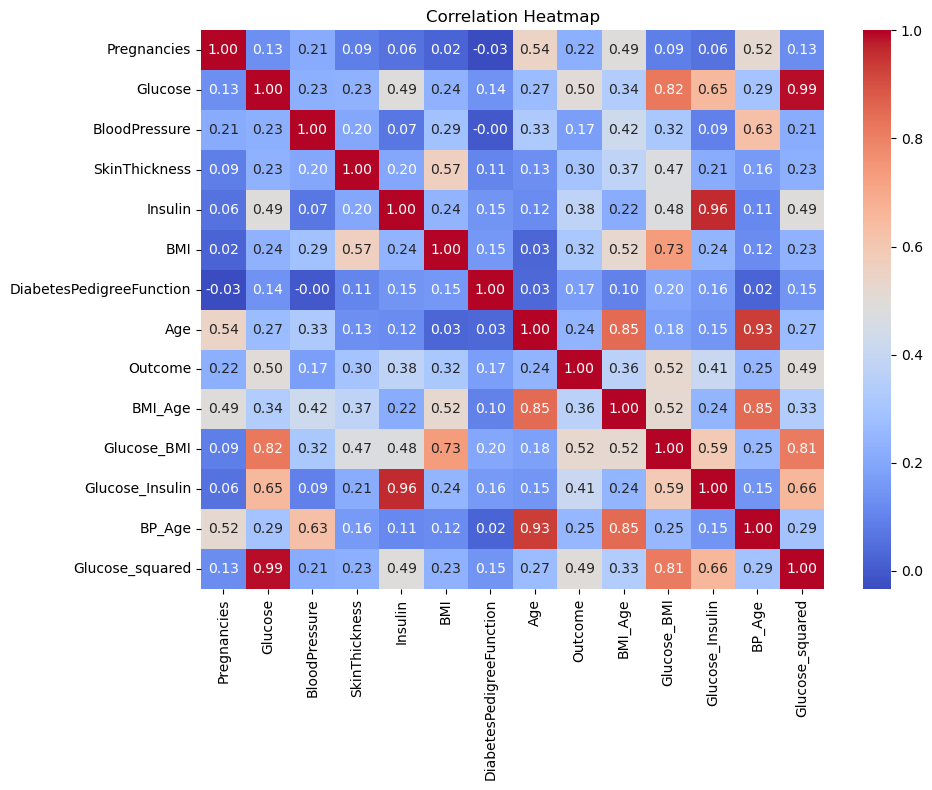

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Train-Test Split & Feature Scaling

In [62]:
# ── Scale features ────
# fit_transform on training set, transform only on test set
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # learns mean/std from TRAINING only
X_test_sc  = scaler.transform(X_test)       # applies same params to test


print('WHY THIS IS CORRECT:')
print('  Model trains on balanced data  → learns both classes equally')
print('  Model tests on real data only  → performance scores are honest')
print('  No data leakage between train and test sets')


WHY THIS IS CORRECT:
  Model trains on balanced data  → learns both classes equally
  Model tests on real data only  → performance scores are honest
  No data leakage between train and test sets


In [63]:
print(X_train.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            7    160.0           54.0           32.0    175.0  30.5   
1           10    148.0           84.0           48.0    237.0  37.6   
2            4     97.0           60.0           23.0    102.5  28.2   
3           10    101.0           86.0           37.0    169.5  45.6   
4            2     92.0           52.0           27.0    102.5  30.1   

   DiabetesPedigreeFunction  Age  BMI_Age  Glucose_BMI  Glucose_Insulin  \
0                     0.588   39   1189.5       4880.0          28000.0   
1                     1.001   51   1917.6       5564.8          35076.0   
2                     0.443   22    620.4       2735.4           9942.5   
3                     1.136   38   1732.8       4605.6          17119.5   
4                     0.141   22    662.2       2769.2           9430.0   

   BP_Age  Glucose_squared  
0  2106.0          25600.0  
1  4284.0          21904.0  
2  1320.0           9409.0  


In [64]:
print(X_test.head())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
44             7    159.0           64.0           27.0    102.5  27.4   
672           10     68.0          106.0           23.0     49.0  35.5   
700            2    122.0           76.0           27.0    200.0  35.9   
630            7    114.0           64.0           32.0    169.5  27.4   
81             2     74.0           70.0           27.0    102.5  30.1   

     DiabetesPedigreeFunction  Age  BMI_Age  Glucose_BMI  Glucose_Insulin  \
44                      0.294   40   1096.0       4356.6          16297.5   
672                     0.285   47   1668.5       2414.0           3332.0   
700                     0.483   26    933.4       4379.8          24400.0   
630                     0.732   34    931.6       3123.6          19323.0   
81                      0.102   22    662.2       2227.4           7585.0   

     BP_Age  Glucose_squared  
44   2560.0          25281.0  
672  4982.0           4624.0  

In [65]:

print("\n Features standardized (mean=0, std=1)")
print(f"Training set scaled: {X_train.shape}")
print(f"Testing set scaled:  {X_test.shape}")




 Features standardized (mean=0, std=1)
Training set scaled: (800, 13)
Testing set scaled:  (154, 13)


In [66]:

# Save scaler for deployment
pickle.dump(scaler, open('scaling.pkl', 'wb'))
pickle.dump(feature_names, open('feature_names.pkl', 'wb'))
print("\n Scaler saved as 'scaling.pkl'")


 Scaler saved as 'scaling.pkl'


In [67]:
X_train



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI,Glucose_Insulin,BP_Age,Glucose_squared
0,7,160.0,54.0,32.0,175.0,30.5,0.588,39,1189.5,4880.0,28000.0,2106.0,25600.0
1,10,148.0,84.0,48.0,237.0,37.6,1.001,51,1917.6,5564.8,35076.0,4284.0,21904.0
2,4,97.0,60.0,23.0,102.5,28.2,0.443,22,620.4,2735.4,9942.5,1320.0,9409.0
3,10,101.0,86.0,37.0,169.5,45.6,1.136,38,1732.8,4605.6,17119.5,3268.0,10201.0
4,2,92.0,52.0,27.0,102.5,30.1,0.141,22,662.2,2769.2,9430.0,1144.0,8464.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,2,96.0,68.0,13.0,49.0,21.1,0.647,26,548.6,2025.6,4704.0,1768.0,9216.0
796,7,124.0,70.0,33.0,215.0,25.5,0.161,37,943.5,3162.0,26660.0,2590.0,15376.0
797,1,97.0,70.0,15.0,102.5,18.2,0.147,21,382.2,1765.4,9942.5,1470.0,9409.0
798,13,129.0,74.5,30.0,169.5,39.9,0.569,44,1755.6,5147.1,21865.5,3278.0,16641.0


In [68]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI,Glucose_Insulin,BP_Age,Glucose_squared
44,7,159.0,64.0,27.0,102.5,27.4,0.294,40,1096.0,4356.6,16297.5,2560.0,25281.0
672,10,68.0,106.0,23.0,49.0,35.5,0.285,47,1668.5,2414.0,3332.0,4982.0,4624.0
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26,933.4,4379.8,24400.0,1976.0,14884.0
630,7,114.0,64.0,32.0,169.5,27.4,0.732,34,931.6,3123.6,19323.0,2176.0,12996.0
81,2,74.0,70.0,27.0,102.5,30.1,0.102,22,662.2,2227.4,7585.0,1540.0,5476.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,3,88.0,58.0,11.0,54.0,24.8,0.267,22,545.6,2182.4,4752.0,1276.0,7744.0
637,2,94.0,76.0,18.0,66.0,31.6,0.649,23,726.8,2970.4,6204.0,1748.0,8836.0
593,2,82.0,52.0,22.0,115.0,28.5,1.699,25,712.5,2337.0,9430.0,1300.0,6724.0
425,4,184.0,78.0,39.0,277.0,37.0,0.264,31,1147.0,6808.0,50968.0,2418.0,33856.0


# Model Training & Comparing 3 Models

 Model 1: Logistic Regression | Model 2: Random Forest | Model 3: Gradient Boosting (XGBoost equivalent)

# Model 1 - Logistic Regression

In [69]:

print('  MODEL 1: LOGISTIC REGRESSION')

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_sc, y_train)

lr_pred  = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]

lr_metrics = {
    'Accuracy' : accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall'   : recall_score(y_test, lr_pred),
    'F1-Score' : f1_score(y_test, lr_pred),
    'ROC-AUC'  : roc_auc_score(y_test, lr_proba)
}

for k, v in lr_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

cm_lr = confusion_matrix(y_test, lr_pred)
tn, fp, fn, tp = cm_lr.ravel()
print(f'\n  Missed Diabetics (FN): {fn}  |  Caught (TP): {tp}')


  MODEL 1: LOGISTIC REGRESSION
  Accuracy    : 0.7857
  Precision   : 0.6438
  Recall      : 0.8704
  F1-Score    : 0.7402
  ROC-AUC     : 0.8237

  Missed Diabetics (FN): 7  |  Caught (TP): 47


# Model 2-Randon Forest 

In [70]:

print('  MODEL 2: RANDOM FOREST + RandomizedSearchCV')

param_dist_rf = {
    'n_estimators'    : [200, 300, 500, 800],
    'max_depth'       : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'    : ['sqrt', 'log2'],
    'class_weight'    : ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(' Running RandomizedSearchCV (30 iterations, 5-fold CV)...')
print('   This may take 2-4 minutes...\n')

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train_sc, y_train)

best_rf   = rf_search.best_estimator_
rf_proba  = best_rf.predict_proba(X_test_sc)[:, 1]

# Use threshold 0.40 for better recall
rf_pred   = (rf_proba >= 0.40).astype(int)

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall'   : recall_score(y_test, rf_pred),
    'F1-Score' : f1_score(y_test, rf_pred),
    'ROC-AUC'  : roc_auc_score(y_test, rf_proba)
}
for k, v in rf_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

cm_rf = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm_rf.ravel()
print(f'\n  Missed Diabetics (FN): {fn}  |  Caught (TP): {tp}')

  MODEL 2: RANDOM FOREST + RandomizedSearchCV
 Running RandomizedSearchCV (30 iterations, 5-fold CV)...
   This may take 2-4 minutes...

Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Accuracy    : 0.8701
  Precision   : 0.7931
  Recall      : 0.8519
  F1-Score    : 0.8214
  ROC-AUC     : 0.9404

  Missed Diabetics (FN): 8  |  Caught (TP): 46


# Model 3- Model 3 — Gradient Boosting (XGBoost equivalent, built into sklearn)



In [71]:

print('  MODEL 3: GRADIENT BOOSTING (XGBoost-style)')

param_dist_gb = {
    'n_estimators'  : [100, 200, 300, 500],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5, 6],
    'subsample'     : [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_base = GradientBoostingClassifier(random_state=42)

print('🔍 Running RandomizedSearchCV for Gradient Boosting...')
print('   This may take 2-4 minutes...\n')

gb_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
gb_search.fit(X_train_sc, y_train)

best_gb  = gb_search.best_estimator_
gb_proba = best_gb.predict_proba(X_test_sc)[:, 1]
gb_pred  = (gb_proba >= 0.40).astype(int)

gb_metrics = {
    'Accuracy' : accuracy_score(y_test, gb_pred),
    'Precision': precision_score(y_test, gb_pred),
    'Recall'   : recall_score(y_test, gb_pred),
    'F1-Score' : f1_score(y_test, gb_pred),
    'ROC-AUC'  : roc_auc_score(y_test, gb_proba)
}

for k, v in gb_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

cm_gb = confusion_matrix(y_test, gb_pred)
tn, fp, fn, tp = cm_gb.ravel()
print(f'\n  Missed Diabetics (FN): {fn}  |  Caught (TP): {tp}')

  MODEL 3: GRADIENT BOOSTING (XGBoost-style)
🔍 Running RandomizedSearchCV for Gradient Boosting...
   This may take 2-4 minutes...

Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Accuracy    : 0.8766
  Precision   : 0.8431
  Recall      : 0.7963
  F1-Score    : 0.8190
  ROC-AUC     : 0.9467

  Missed Diabetics (FN): 11  |  Caught (TP): 43


In [72]:
# ── Build comparison DataFrame ────────────────────────────
comparison_df = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy' : [lr_metrics['Accuracy'],  rf_metrics['Accuracy'],  gb_metrics['Accuracy']],
    'Precision': [lr_metrics['Precision'], rf_metrics['Precision'], gb_metrics['Precision']],
    'Recall'   : [lr_metrics['Recall'],    rf_metrics['Recall'],    gb_metrics['Recall']],
    'F1-Score' : [lr_metrics['F1-Score'],  rf_metrics['F1-Score'],  gb_metrics['F1-Score']],
    'ROC-AUC'  : [lr_metrics['ROC-AUC'],   rf_metrics['ROC-AUC'],   gb_metrics['ROC-AUC']]
}).set_index('Model').round(4)

# Highlight best values
styled = comparison_df.style.highlight_max(axis=0, color='#c8e6c9').format('{:.4f}')

print('\n MODEL COMPARISON TABLE (green = best in column):')
print()
print(comparison_df.to_string())

# Find best model by ROC-AUC
best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f'\n Best Model by ROC-AUC: {best_model_name} ({comparison_df.loc[best_model_name, "ROC-AUC"]:.4f})')
print(f' Best Model by Recall : {comparison_df["Recall"].idxmax()} ({comparison_df["Recall"].max():.4f})')

styled


 MODEL COMPARISON TABLE (green = best in column):

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7857     0.6438  0.8704    0.7402   0.8237
Random Forest          0.8701     0.7931  0.8519    0.8214   0.9404
Gradient Boosting      0.8766     0.8431  0.7963    0.8190   0.9467

 Best Model by ROC-AUC: Gradient Boosting (0.9467)
 Best Model by Recall : Logistic Regression (0.8704)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7857,0.6438,0.8704,0.7402,0.8237
Random Forest,0.8701,0.7931,0.8519,0.8214,0.9404
Gradient Boosting,0.8766,0.8431,0.7963,0.8190,0.9467


In [75]:
print('THRESHOLD ANALYSIS — RANDOM FOREST:')
print(f'{"Threshold":>12}  {"Accuracy":>10}  {"Recall":>8}  {"Precision":>11}  {"F1":>8}  {"FN (missed)":>12}')

thresholds   = [0.5, 0.45, 0.40, 0.35, 0.30]
thresh_data  = []

for t in thresholds:
    y_t = (rf_proba >= t).astype(int)
    _, _, fn_t, tp_t = confusion_matrix(y_test, y_t).ravel()
    row = {
        'threshold': t,
        'accuracy' : accuracy_score(y_test, y_t),
        'recall'   : recall_score(y_test, y_t),
        'precision': precision_score(y_test, y_t),
        'f1'       : f1_score(y_test, y_t),
        'fn'       : fn_t
    }
    thresh_data.append(row)
    marker = '  ←  Recommended' if t == 0.40 else ''
    print(f'{t:>12.2f}  {row["accuracy"]:>10.4f}  {row["recall"]:>8.4f}  {row["precision"]:>11.4f}  {row["f1"]:>8.4f}  {fn_t:>12}{marker}')

print('\n Threshold 0.40 recommended: best balance of Recall without destroying Precision')
print('   In medical use: reducing FN (missed diabetics) is the top priority')

THRESHOLD ANALYSIS — RANDOM FOREST:
   Threshold    Accuracy    Recall    Precision        F1   FN (missed)
        0.50      0.8701    0.7963       0.8269    0.8113            11
        0.45      0.8636    0.8148       0.8000    0.8073            10
        0.40      0.8701    0.8519       0.7931    0.8214             8  ←  Recommended
        0.35      0.8571    0.8704       0.7581    0.8103             7
        0.30      0.8701    0.9074       0.7656    0.8305             5

 Threshold 0.40 recommended: best balance of Recall without destroying Precision
   In medical use: reducing FN (missed diabetics) is the top priority


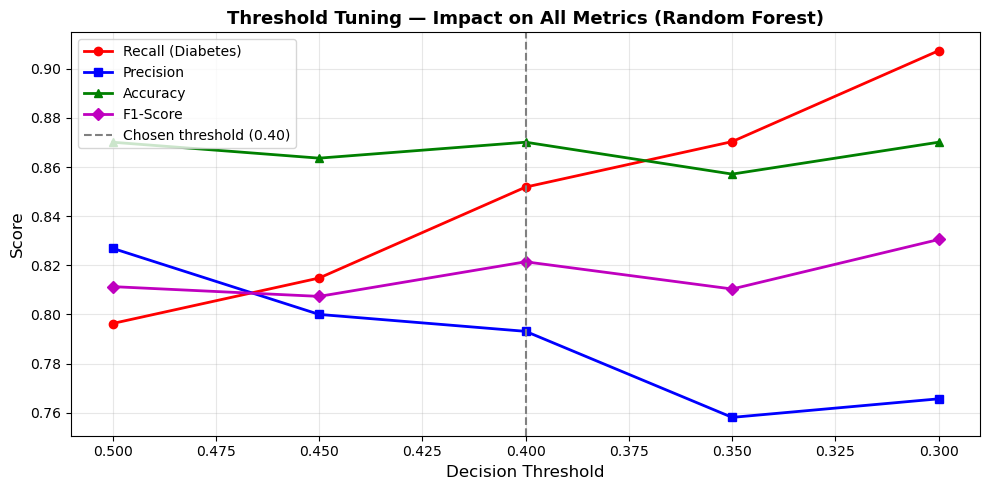

In [81]:
# ── Threshold vs Metrics (Random Forest) ──────────────────
thresh_df = pd.DataFrame(thresh_data)

plt.figure(figsize=(10, 5))
plt.plot(thresh_df['threshold'], thresh_df['recall'],    'r-o', lw=2, label='Recall (Diabetes)')
plt.plot(thresh_df['threshold'], thresh_df['precision'], 'b-s', lw=2, label='Precision')
plt.plot(thresh_df['threshold'], thresh_df['accuracy'],  'g-^', lw=2, label='Accuracy')
plt.plot(thresh_df['threshold'], thresh_df['f1'],        'm-D', lw=2, label='F1-Score')
plt.axvline(x=0.40, color='gray', linestyle='--', lw=1.5, label='Chosen threshold (0.40)')
plt.gca().invert_xaxis()
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Threshold Tuning — Impact on All Metrics (Random Forest)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=200, bbox_inches='tight')
plt.show()



In [82]:
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS:')
print('Note: CV runs on balanced training data (oversampled) — honest evaluation')
print()

# Use the scaled training data for cross-validation
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = [
    ('Logistic Regression', lr_model),
    ('Random Forest',        best_rf),
    ('Gradient Boosting',    best_gb)
]

for name, model in cv_models:
    print(f'  {name}:')
    for scoring in ['roc_auc', 'recall', 'f1']:
        scores = cross_val_score(model, X_train_sc, y_train, cv=skf_cv, scoring=scoring)
        label  = scoring.upper().replace('_', '-')
        print(f'    {label:10s}: {scores.mean():.4f} ± {scores.std():.4f}')
    print()

print(' Cross-validation complete!')

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS:
Note: CV runs on balanced training data (oversampled) — honest evaluation

  Logistic Regression:
    ROC-AUC   : 0.8687 ± 0.0329
    RECALL    : 0.8225 ± 0.0300
    F1        : 0.8124 ± 0.0207

  Random Forest:
    ROC-AUC   : 0.9814 ± 0.0104
    RECALL    : 0.9700 ± 0.0127
    F1        : 0.9309 ± 0.0196

  Gradient Boosting:
    ROC-AUC   : 0.9829 ± 0.0083
    RECALL    : 0.9600 ± 0.0242
    F1        : 0.9367 ± 0.0133

 Cross-validation complete!


In [98]:
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                     insulin, bmi, diabetes_pedigree, age):
    """
    Predict diabetes for a new patient.
    Inputs : 8 standard Pima dataset features
    Returns: prediction dict with result, probability, and risk level
    """
    model      = pickle.load(open('diabetes_model.pkl',  'rb'))
    sc         = pickle.load(open('scaling.pkl',         'rb'))
    threshold  = pickle.load(open('threshold.pkl',       'rb'))
    feat_names = pickle.load(open('feature_names.pkl',   'rb'))

    # ── Build all features (base + engineered) ─────────────
    data = {
        'Pregnancies'             : pregnancies,
        'Glucose'                 : glucose,
        'BloodPressure'           : blood_pressure,
        'SkinThickness'           : skin_thickness,
        'Insulin'                 : insulin,
        'BMI'                     : bmi,
        'DiabetesPedigreeFunction': diabetes_pedigree,
        'Age'                     : age,
        'BMI_Age'                 : bmi * age,
        'Glucose_BMI'             : glucose * bmi,
        'Glucose_Insulin'         : glucose * insulin,
        'BP_Age'                  : blood_pressure * age,
        'Glucose_squared'         : glucose ** 2
    }

    input_df     = pd.DataFrame([data])[feat_names]
    input_scaled = sc.transform(input_df)
    prob         = model.predict_proba(input_scaled)[0][1]
    pred         = 1 if prob >= threshold else 0

    if   prob >= 0.70: risk = '  HIGH RISK'
    elif prob >= 0.40: risk = '  MODERATE RISK'
    else:              risk = '  LOW RISK'

    print('\n' + '='*52)
    print('     DIABETES PREDICTION RESULT')
    print('='*52)
    print(f'   Result      : {" DIABETES DETECTED" if pred == 1 else "  No Diabetes"}')
    print(f'   Probability : {prob:.1%}')
    print(f'   Risk Level  : {risk}')
    print(f'   Threshold   : {threshold}')
    print('='*52)
    if pred == 1:
        print('    Recommendation: Please consult a doctor.')
    return {'prediction': pred, 'probability': prob, 'risk': risk}

print(' predict_diabetes() function ready!')
print('   Usage: predict_diabetes(pregnancies, glucose, blood_pressure,')
print('                           skin_thickness, insulin, bmi, pedigree, age)')

 predict_diabetes() function ready!
   Usage: predict_diabetes(pregnancies, glucose, blood_pressure,
                           skin_thickness, insulin, bmi, pedigree, age)


In [99]:
# ── Test with a sample patient ─────────────────────────────
result = predict_diabetes(
    pregnancies      = 6,
    glucose          = 148,
    blood_pressure   = 72,
    skin_thickness   = 35,
    insulin          = 150,
    bmi              = 33.6,
    diabetes_pedigree= 0.627,
    age              = 50
)


     DIABETES PREDICTION RESULT
   Result      :  DIABETES DETECTED
   Probability : 100.0%
   Risk Level  :   HIGH RISK
   Threshold   : 0.4
    Recommendation: Please consult a doctor.


In [100]:
# ── Test with a healthy patient ────────────────────────────
result2 = predict_diabetes(
    pregnancies      = 1,
    glucose          = 95,
    blood_pressure   = 70,
    skin_thickness   = 20,
    insulin          = 80,
    bmi              = 22.0,
    diabetes_pedigree= 0.167,
    age              = 25
)


     DIABETES PREDICTION RESULT
   Result      :   No Diabetes
   Probability : 0.0%
   Risk Level  :   LOW RISK
   Threshold   : 0.4


In [107]:
result3 = predict_diabetes(
    pregnancies      = 4,      # how many times pregnant
    glucose          = 168,    # glucose level mg/dL
    blood_pressure   = 88,     # blood pressure mm Hg
    skin_thickness   = 42,     # skin thickness mm
    insulin          = 270,    # insulin mu U/ml  (use 0 if unknown)
    bmi              = 39.6,   # BMI kg/m²
    diabetes_pedigree= 0.881,   # pedigree score
    age              = 52      # age in years
)


     DIABETES PREDICTION RESULT
   Result      :  DIABETES DETECTED
   Probability : 100.0%
   Risk Level  :   HIGH RISK
   Threshold   : 0.4
    Recommendation: Please consult a doctor.
